In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
stocks = [
    "PG",
    "KO",
    "PEP",
    "WMT",
    "COST"
]

In [5]:
startDate = "2015-01-01"
endDate = "2026-01-01"

In [7]:
data = yf.download(
    stocks,
    start=startDate,
    end=endDate
)

[*********************100%***********************]  5 of 5 completed


In [9]:
data.head()

Price            Close                                              \
Ticker            COST         KO        PEP         PG        WMT   
Date                                                                 
2015-01-02  113.815125  29.390261  66.582939  65.555733  23.127542   
2015-01-05  112.521172  29.390261  66.082367  65.244049  23.060234   
2015-01-06  114.008072  29.613449  65.581810  64.946877  23.237938   
2015-01-07  115.993195  29.983089  67.499474  65.287560  23.854485   
2015-01-08  116.989914  30.345762  68.726219  66.034142  24.357962   

Price             High                                              ...  \
Ticker            COST         KO        PEP         PG        WMT  ...   
Date                                                                ...   
2015-01-02  115.052852  29.571597  67.217461  65.961649  23.348319  ...   
2015-01-05  114.257215  29.969140  67.013005  65.961652  23.240624  ...   
2015-01-06  114.884127  29.948222  66.709861  65.642735  23.356403  ...   
2015-01-07  116.081592  30.066782  67.844942  65.505018  23.876024  ...   
2015-01-08  117.423931  30.387610  69.029382  66.128376  24.411808  ...   

Price             Open                                               Volume  \
Ticker            COST         KO        PEP         PG        WMT     COST   
Date                                                                          
2015-01-02  114.024088  29.473953  66.928402  65.845670  23.227160  1471000   
2015-01-05  113.879465  29.773854  66.589983  65.403518  23.079082  1748500   
2015-01-06  113.011451  29.578577  66.329145  65.461522  23.149089  3185200   
2015-01-07  114.610791  29.850574  67.069405  65.193331  23.364472  2171600   
2015-01-08  116.989914  30.115607  68.204494  65.584736  24.018722  2937700   

Price                                             
Ticker            KO      PEP       PG       WMT  
Date                                              
2015-01-02   9921100  3545700  7251400  13505400  
2015-01-05  26292600  6441000  8626100  20937000  
2015-01-06  16897500  6195000  7791200  24615300  
2015-01-07  13412300  6526300  5986600  25495200  
2015-01-08  21743600  7131600  6823300  38140800  

[5 rows x 25 columns]

In [11]:
prices = data["Close"]

prices.head()

Ticker,COST,KO,PEP,PG,WMT
Date,,,,,
2015-01-02,113.815125,29.390261,66.582939,65.555733,23.127542
2015-01-05,112.521172,29.390261,66.082367,65.244049,23.060234
2015-01-06,114.008072,29.613449,65.581810,64.946877,23.237938
2015-01-07,115.993195,29.983089,67.499474,65.287560,23.854485
2015-01-08,116.989914,30.345762,68.726219,66.034142,24.357962


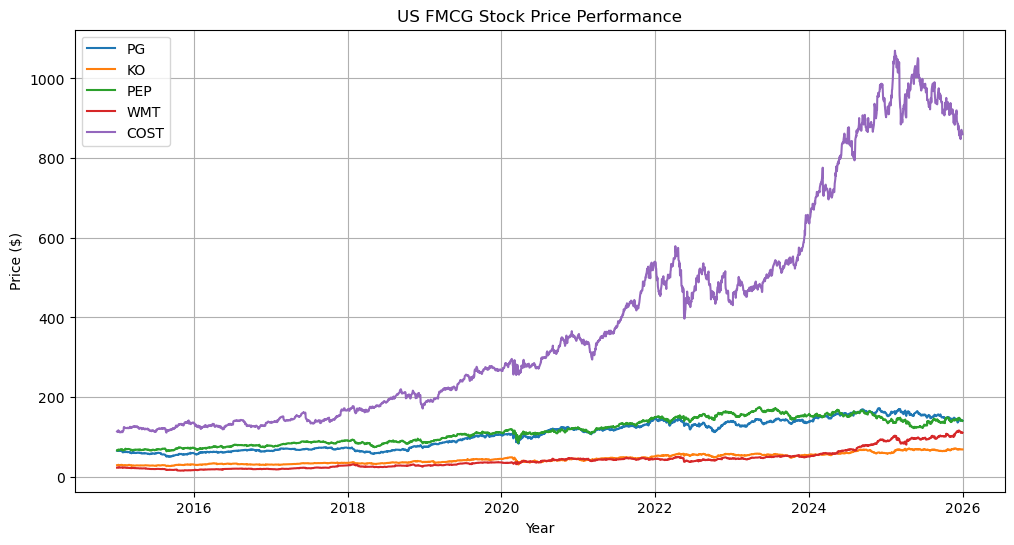

In [15]:
plt.figure(figsize=(12,6))


for stock in stocks:
    plt.plot(
        prices[stock],
        label=stock
    )
    plt.title("US FMCG Stock Price Performance")
plt.xlabel("Year")
plt.ylabel("Price ($)")
plt.legend()
plt.grid()

plt.show()

In [17]:
daily_returns = prices.pct_change()


daily_returns.head()

Ticker,COST,KO,PEP,PG,WMT
Date,,,,,
2015-01-02,NaN,NaN,NaN,NaN,NaN
2015-01-05,-0.011369,0.000000,-0.007518,-0.004754,-0.002910
2015-01-06,0.013214,0.007594,-0.007575,-0.004555,0.007706
2015-01-07,0.017412,0.012482,0.029241,0.005246,0.026532
2015-01-08,0.008593,0.012096,0.018174,0.011435,0.021106


In [19]:
daily_returns.describe()

Ticker,COST,KO,PEP,PG,WMT
count,2765.000000,2765.000000,2765.000000,2765.000000,2765.000000
mean,0.000824,0.000372,0.000343,0.000346,0.000659
std,0.013594,0.011187,0.011989,0.011662,0.013551
min,-0.124513,-0.096725,-0.114283,-0.087373,-0.113758
25%,-0.005599,-0.004708,-0.005184,-0.005126,-0.005622
50%,0.001036,0.000482,0.000381,0.000579,0.000738
75%,0.007634,0.005886,0.006147,0.006287,0.007080
max,0.099594,0.064796,0.129366,0.120090,0.117085


In [21]:
annual_return = daily_returns.mean()*252


annual_return

Ticker
COST    0.207718
KO      0.093621
PEP     0.086379
PG      0.087085
WMT     0.166069
dtype: float64

In [23]:
annual_volatility = daily_returns.std()*np.sqrt(252)


annual_volatility

Ticker
COST    0.215804
KO      0.177590
PEP     0.190322
PG      0.185132
WMT     0.215112
dtype: float64

In [25]:
risk_free_rate = 0.04


sharpe_ratio = (
    annual_return - risk_free_rate
) / annual_volatility


sharpe_ratio

Ticker
COST    0.777175
KO      0.301936
PEP     0.243690
PG      0.254331
WMT     0.586062
dtype: float64

In [27]:
performance = pd.DataFrame({

    "Annual Return": annual_return,

    "Annual Volatility": annual_volatility,

    "Sharpe Ratio": sharpe_ratio

})


performance

,Annual Return,Annual Volatility,Sharpe Ratio
Ticker,,,
COST,0.207718,0.215804,0.777175
KO,0.093621,0.177590,0.301936
PEP,0.086379,0.190322,0.243690
PG,0.087085,0.185132,0.254331
WMT,0.166069,0.215112,0.586062


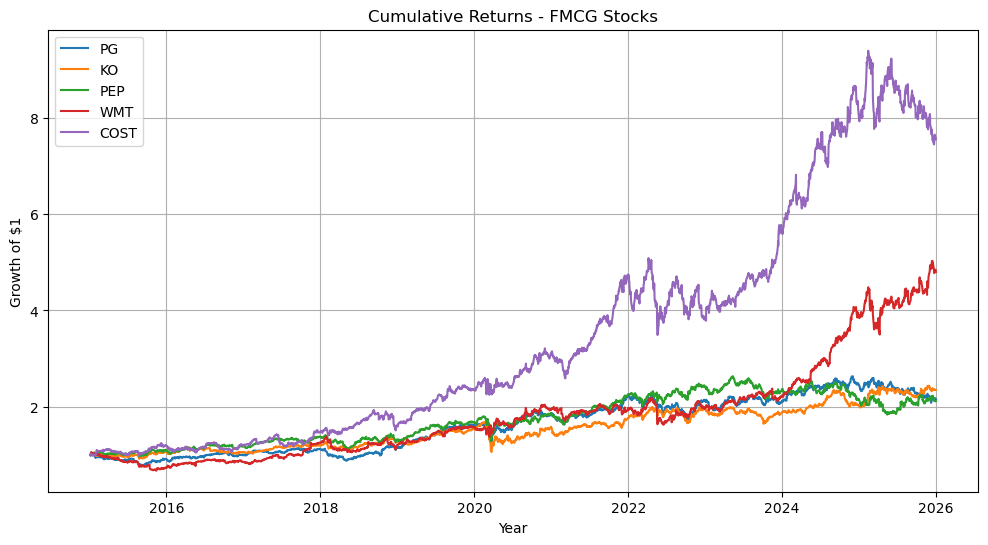

In [29]:
cumulative_returns = (
    1 + daily_returns
).cumprod()


plt.figure(figsize=(12,6))


for stock in stocks:

    plt.plot(
        cumulative_returns[stock],
        label=stock
    )


plt.title(
    "Cumulative Returns - FMCG Stocks"
)

plt.xlabel("Year")

plt.ylabel("Growth of $1")


plt.legend()
plt.grid()

plt.show()

In [31]:
correlation = daily_returns.corr()


correlation

Ticker,COST,KO,PEP,PG,WMT
Ticker,,,,,
COST,1.000000,0.399961,0.456372,0.439729,0.560817
KO,0.399961,1.000000,0.722526,0.622545,0.353402
PEP,0.456372,0.722526,1.000000,0.686452,0.427153
PG,0.439729,0.622545,0.686452,1.000000,0.437108
WMT,0.560817,0.353402,0.427153,0.437108,1.000000


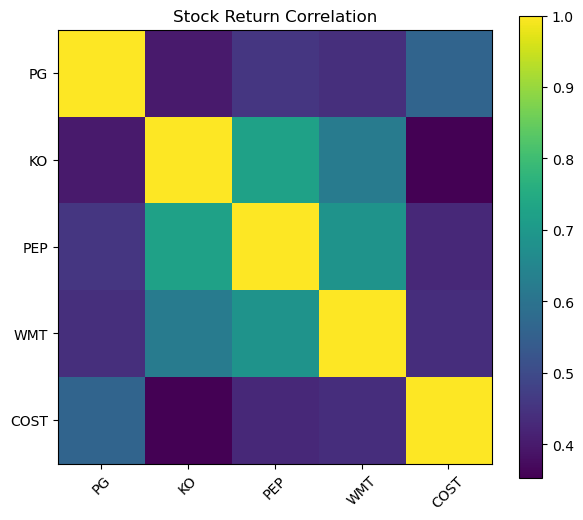

In [33]:
plt.figure(figsize=(7,6))


plt.imshow(correlation)


plt.colorbar()


plt.xticks(
    range(len(stocks)),
    stocks,
    rotation=45
)


plt.yticks(
    range(len(stocks)),
    stocks
)


plt.title(
    "Stock Return Correlation"
)


plt.show()

In [35]:
weights = np.array(
    [0.20,0.20,0.20,0.20,0.20]
)


portfolio_daily_return = (
    daily_returns.dot(weights)
)


portfolio_daily_return.head()

Date
2015-01-02         NaN
2015-01-05   -0.005310
2015-01-06    0.003277
2015-01-07    0.018183
2015-01-08    0.014281
dtype: float64

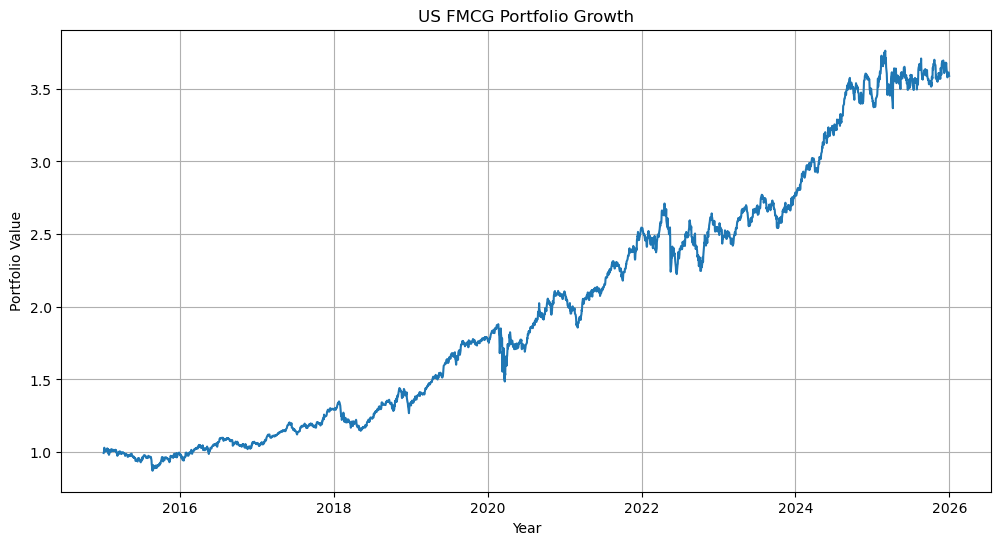

In [37]:
portfolio_growth = (
    1 + portfolio_daily_return
).cumprod()


plt.figure(figsize=(12,6))


plt.plot(portfolio_growth)


plt.title(
    "US FMCG Portfolio Growth"
)


plt.xlabel("Year")

plt.ylabel("Portfolio Value")


plt.grid()

plt.show()

In [39]:
portfolio_return = (
    portfolio_daily_return.mean()*252
)


portfolio_volatility = (
    portfolio_daily_return.std()*np.sqrt(252)
)


portfolio_sharpe = (
    portfolio_return-risk_free_rate
) / portfolio_volatility



print(
"Annual Return:",
portfolio_return
)


print(
"Annual Risk:",
portfolio_volatility
)


print(
"Sharpe Ratio:",
portfolio_sharpe
)

Annual Return: 0.12817436184932682
Annual Risk: 0.1529930627363672
Sharpe Ratio: 0.5763291503044558


In [41]:
portfolio_value = (
    1 + portfolio_daily_return
).cumprod()


peak = portfolio_value.cummax()


drawdown = (
    portfolio_value - peak
) / peak


max_drawdown = drawdown.min()


print(
"Maximum Drawdown:",
max_drawdown
)

Maximum Drawdown: -0.20972977734214313


In [43]:
VaR = np.percentile(
    portfolio_daily_return.dropna(),
    5
)


print(
"95% Daily VaR:",
VaR
)

95% Daily VaR: -0.013503610299140743
